# Dot Histogram Code

Creates a plot of dot brightness, and finds FWHM in nm.  Plots a histogram of the data.

In [216]:
import sif_parser
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import scipy as sp 
from scipy import stats 
import xarray as xr

Same code from andor_tracking_analysis.ipynb for opening the file.

{'SifVersion': 65567, 'ExperimentTime': 1739614576, 'DetectorTemperature': -999.0, 'ExposureTime': 0.001, 'CycleTime': 0.29361, 'AccumulatedCycleTime': 0.29361, 'AccumulatedCycles': 1, 'StackCycleTime': 0.29361, 'PixelReadoutTime': 1e-06, 'GainDAC': 100.0, 'GateWidth': 0.0, 'GratingBlaze': 3.3e-06, 'DetectorType': 'DU897_BV', 'DetectorDimensions': (512, 512), 'OriginalFilename': 'C:\\Users\\Lab\\Desktop\\DATA\\Tomny\\2025\\2025_02_14\\overnight_spot1.sif', 'ShutterTime': (0.0, 0.0), 'spectrograph': 'Spectrograph_None999', 'GateGain': 0.0, 'GateDelay': 0.0, 'SifCalbVersion': 65540, 'RamanExWavelength': 422.0, 'FrameAxis': 'Pixel number', 'DataType': 'Counts', 'ImageAxis': 'Pixel number', 'NumberOfFrames': 500, 'NumberOfSubImages': 1, 'TotalLength': 131072000, 'ImageLength': 262144, 'xbin': 1, 'ybin': 1, 'size': (512, 512), 'offset': 8329}
0.001
0.29361
500


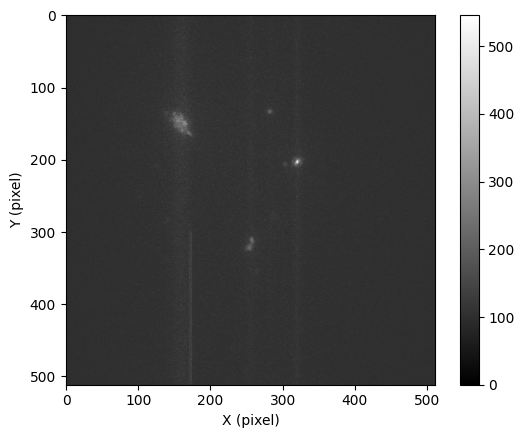

In [61]:
# Open the SIF file. 512x512 is pixel size of the camera
filename = '/Users/aprill/Library/CloudStorage/OneDrive-Personal/Documents/UW/Research/Kai-Mei/Data/OneDrive_1_2-19-2025/overnight_spot1.sif'
data = sif_parser.xr_open(filename)
print(data.attrs)
print(data.ExposureTime) # exposure time of when shutter opens to close. Check docs on andor for exact time
print(data.CycleTime) #time when shutter opens to next time when shutter OPENS. Check andor docs to see exact time
print(data.NumberOfFrames) # obvious 
# Access the data array. # axis 0 is frame, axis 1 is the y axis in the image and axis 2 is the x axis in the image
image_data = data.values

# getting rid of the dead pixels of the line for the andor camera
# Set the selected region to the average of the 10 pixels around it
# would be better to bkg subtract but the pixels change in intensity depending on laser power so would have to do this for every power
for i in range(image_data.shape[0]):
    for j in range(290, image_data.shape[1]):
        for k in range(171, 173):
            image_data[i, j, k] = np.mean(image_data[i, max(0, j-10):min(image_data.shape[1], j+10), max(0, k-10):min(image_data.shape[2], k+10)])

# Plot the image
plt.figure()
framenum = 0
plt.imshow(image_data[framenum], cmap="gray", vmin=0)
plt.xlabel('X (pixel)')
plt.ylabel('Y (pixel)')
plt.colorbar()
plt.show()

Using a radius of 5 px


<Axes: >

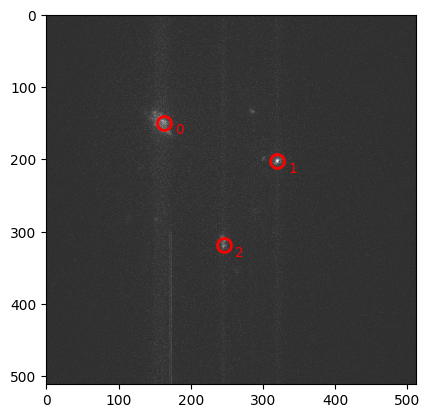

In [190]:
# this is for qds, and will try to optimize for tethered beads
import pandas as pd
from pandas import DataFrame, Series  # for convenience
import trackpy as tp

# Finding the radius of the feature
micron_per_pixel = 20/80.056 # for andor camera
feature_diameter = 2 # um. good to err on large side for this package.
radius = int(np.round(feature_diameter/2.0/micron_per_pixel))
if radius % 2 ==  0:
    radius += 1
print('Using a radius of {:d} px'.format(radius))

# PARAMETERS TO BE CHANGED
frames = image_data
frame_num = 20
r = radius + 10 # we use a slightly larger radius for error in case it's larger (clumps of qds)
minmass = 1250 # minimum integrated brightness of feature, https://soft-matter.github.io/trackpy/dev/generated/trackpy.locate.html 
threshold = 20 # threshold could be useful which eliminates noise below value. might want to bkg subrtract first
percentile = 90 # choose >90th brightest percentile of image for feature selection
plt.figure()
f_locate = tp.locate(frames[frame_num], r, minmass=minmass, threshold=threshold, percentile = percentile) 

# added annotation of the plot with the respective number.
for i in np.arange(0, len(f_locate)):                                       
    plt.text(f_locate['x'][i]+15,f_locate['y'][i]+15,f'{i}', color='red')

tp.annotate(f_locate, frames[frame_num], plot_style={'markersize': radius*2}, ax=plt.gca(), imshow_style={'cmap':'gray', 'vmin':0})

Optional cell that finds the brightest spot within a parameter few pixel area of the exact found dot location from previous.  Just to ensure actually centering on the dot.

In [237]:
test_width = 5 # width around found x and y to test for max brightness
optimize = True # choose whether to look for max counts around the found dot or to keep the points found by the optimization
frame = 20

plot_y_horiz = xr.DataArray(data=np.random.randn(len(f_locate), 512), dims=("dot", "x")) # 2d array holding the horizontal values of the dot max y val
plot_y_vert = xr.DataArray(data=np.random.randn(len(f_locate), 512), dims=("dot", "y")) # 2d array holding the vertical values of the dot max x val
x_max_index = np.zeros(len(f_locate)) # holds the x index of the max point of each dot
y_max_index = np.zeros(len(f_locate)) 

if optimize == True:
    for i in np.arange(0, len(f_locate)): #testing for where the max brightness is around the found coordinate
        max_val = 0 # keeping track of max counts
        max_ind = 0 # keeping track of how far away the max is from the found coordinate
        max_array_ind = 0 # keeping track of the x coordinate of the max value
        for j in np.arange(-test_width, test_width):
            max_temp = np.max(frames[frame,round(f_locate['y'][i])+j,(round(f_locate['x'][i])-test_width):(round(f_locate['x'][i])+test_width)])
            if max_temp > max_val:
                max_val = max_temp
                max_ind = j
                for k in np.arange(round(f_locate['x'][i]) - test_width, round(f_locate['x'][i]) + test_width):
                    if max_val == np.max(frames[frame,round(f_locate['y'][i])+j,k]):
                        max_array_ind = k

        x_max_index[i] = max_array_ind
        y_max_index[i] = int(round(f_locate['y'][i])+max_ind)
        plot_y_horiz[i] = frames[frame,int(round(f_locate['y'][i])+max_ind),:]
        plot_y_vert[i] = frames[frame,:,max_array_ind]
else:
    for i in np.arange(0, len(f_locate)):
        x_max_index[i] = int(round(f_locate['x'][i]))
        y_max_index[i] = int(round(f_locate['y'][i]))
        plot_y_horiz[i] = frames[frame,int(round(f_locate['y'][i])),:]
        plot_y_vert[i] = frames[frame,:,int(round(f_locate['x'][i]))]

Cell to plot the data (can choose which ones to plot through plot_num)

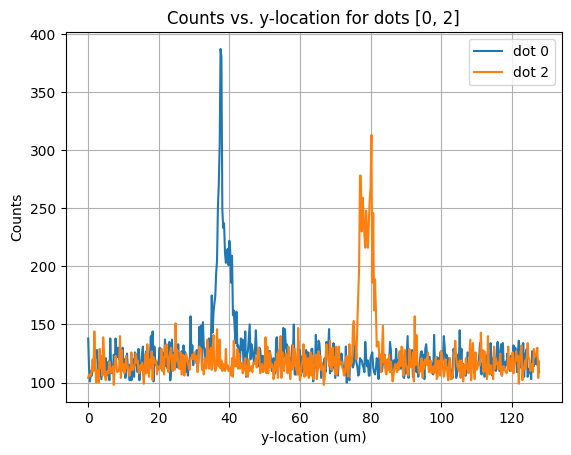

In [215]:
plot_num = [0,2] # choose which dots to plot 
dimension = 0 # choose vertical or horizontal - vertical is 0, horizontal is 1.

plot_x = np.arange(0,20/80.056*512,20/80.056) # scale of x points is in microns

for i in plot_num:
    if dimension == 0:
        ypoints = plot_y_vert[i]
        plt.plot(plot_x, ypoints, label=f"dot {i}")
    if dimension == 1:
        ypoints = plot_y_horiz[i]
        plt.plot(plot_x, ypoints, label=f"dot {i}") 

label = ''
if dimension == 0:
    label='y'
else:
    label='x'

plt.xlabel(f"{label}-location (um)")
plt.ylabel("Counts")
plt.title(f"Counts vs. {label}-location for dots {plot_num}")
plt.legend()
plt.grid()
plt.show()

Find the Gaussian fit for each data set. Similar to before, choose which to plot.

In [217]:
def gauss(x, H, A, x0, sigma): 
    return H + A * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2))

In [241]:
plot_x = np.arange(0,20/80.056*512,20/80.056) # just showing the x values again.
fit_horiz = xr.DataArray(data=np.random.randn(len(f_locate), 4), dims=("dot", "x")) # 2d array holding the parameters of the fit for the horizontal graphs
fit_vert = xr.DataArray(data=np.random.randn(len(f_locate), 4), dims=("dot", "y")) # 2d array holding the parameters of the fit for the vertical graphs

for i in np.arange(0,len(f_locate)):
    parameters, covariance = sp.optimize.curve_fit(gauss, plot_x, plot_y_horiz[i], p0=[1, 1, float(x_max_index[i]*20/80.056), 1]) 
    fit_horiz[i] = parameters
    parameters, covariance = sp.optimize.curve_fit(gauss, plot_x, plot_y_vert[i], p0=[1, 1, float(y_max_index[i]*20/80.056), 1]) 
    fit_vert[i] = parameters

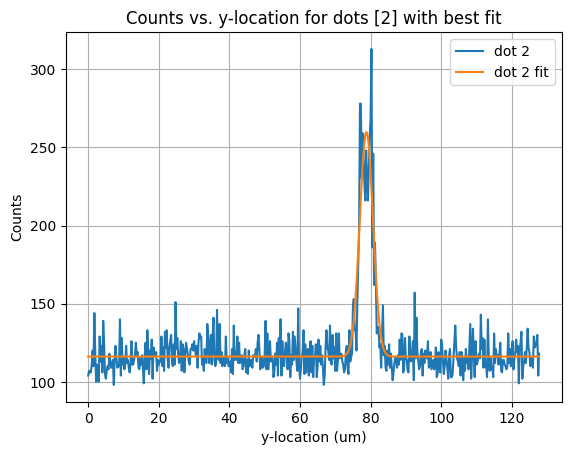

In [244]:
plot_num = [2] # choose which dots to plot 
dimension = 0 # choose vertical or horizontal - vertical is 0, horizontal is 1.

plot_x = np.arange(0,20/80.056*512,20/80.056) # scale of x points is in microns

for i in plot_num:
    if dimension == 0:
        ypoints = plot_y_vert[i]
        plt.plot(plot_x, ypoints, label=f"dot {i}")
        plt.plot(plot_x, gauss(plot_x, float(fit_vert[i][0]),float(fit_vert[i][1]),float(fit_vert[i][2]),float(fit_vert[i][3])), label = f"dot {i} fit") # There has to be a better way to do this
    if dimension == 1:
        ypoints = plot_y_horiz[i]
        plt.plot(plot_x, ypoints, label=f"dot {i}") 
        plt.plot(plot_x, gauss(plot_x, float(fit_horiz[i][0]),float(fit_horiz[i][1]),float(fit_horiz[i][2]),float(fit_horiz[i][3])),label = f"dot {i} fit")

label = ''
if dimension == 0:
    label='y'
else:
    label='x'

plt.xlabel(f"{label}-location (um)")
plt.ylabel("Counts")
plt.title(f"Counts vs. {label}-location for dots {plot_num} with best fit")
plt.legend()
plt.grid()
plt.show()

Plot the FWHM as a histogram or just a regular scatter plot - there aren't usually that many dots so I'm not sure how well a histogram would represent.  I'll include both here.  Histogram first, scatter plot second.

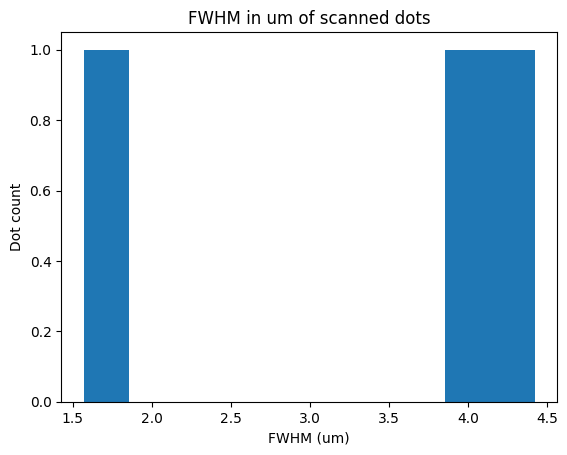

In [247]:
dimension = 0 # choose vertical or horizontal - vertical is 0, horizontal is 1.
hist_data = np.zeros(len(f_locate)) # holds the fwhm for the histogram

for i in np.arange(0,len(f_locate)):
    if dimension == 0:
        hist_data[i] = abs(fit_vert[i][3]) * 2.355
    if dimension == 1:
        hist_data[i] = abs(fit_horiz[i][3]) * 2.355
plt.hist(hist_data)
plt.xlabel("FWHM (um)")
plt.ylabel("Dot count")
plt.title("FWHM in um of scanned dots")
plt.show() 

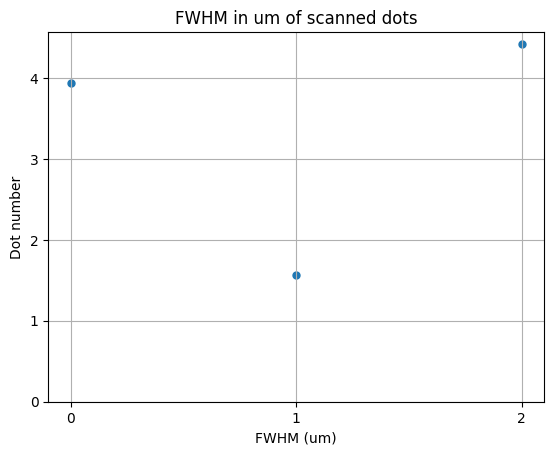

In [269]:
dimension = 0 # choose vertical or horizontal - vertical is 0, horizontal is 1.
y_data = np.zeros(len(f_locate)) # holds the fwhm values for the plot

for i in np.arange(0,len(f_locate)):
    if dimension == 0:
        y_data[i] = abs(fit_vert[i][3]) * 2.355
    if dimension == 1:
        y_data[i] = abs(fit_horiz[i][3]) * 2.355
plt.scatter(np.arange(0,len(f_locate)), y_data,s=25)
plt.xlabel("FWHM (um)")
plt.ylabel("Dot number")
y_int = np.arange(0, len(f_locate))
plt.xticks(y_int)
plt.ylim(ymin=0)
plt.title("FWHM in um of scanned dots")
plt.grid()
plt.show() 